In [6]:
!pip install rpy2

In [7]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [8]:
%%R
install.packages('mlbench')
install.packages('dplyr')
install.packages('ggplot2')

library(mlbench)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/mlbench_2.1-8.tar.gz'
Content type 'application/x-gzip' length 992336 bytes (969 KB)
downloaded 969 KB


The downloaded source packages are in
	‘/tmp/RtmpbqX7sG/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
Content type 'application/x-gzip' length 923509 bytes (901 KB)
downloaded 901 KB


The downloaded source packages are in
	‘/tmp/RtmpbqX7sG/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpbqX7sG/downloaded_packages’

Attaching package: ‘dplyr’

The following objects are masked 

In [9]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    file_name = fn
    print(f'Uploaded: {fn}')

Saving data.csv to data.csv
Uploaded: data.csv


In [10]:
%%R -i file_name

my_data <- read.csv("data.csv")
head(my_data)

        id diagnosis radius_mean texture_mean perimeter_mean area_mean
1   842302         M       17.99        10.38         122.80    1001.0
2   842517         M       20.57        17.77         132.90    1326.0
3 84300903         M       19.69        21.25         130.00    1203.0
4 84348301         M       11.42        20.38          77.58     386.1
5 84358402         M       20.29        14.34         135.10    1297.0
6   843786         M       12.45        15.70          82.57     477.1
  smoothness_mean compactness_mean concavity_mean concave.points_mean
1         0.11840          0.27760         0.3001             0.14710
2         0.08474          0.07864         0.0869             0.07017
3         0.10960          0.15990         0.1974             0.12790
4         0.14250          0.28390         0.2414             0.10520
5         0.10030          0.13280         0.1980             0.10430
6         0.12780          0.17000         0.1578             0.08089
  symmetry_me

In [11]:
%%R
# Check for missing values
any(is.na(my_data))
sum(is.na(my_data))

# Remove useless columns (id is just a number, X is empty)
corrected_data <- my_data[, !(names(my_data) %in% c("id", "X"))]

# Check for duplicates
any(duplicated(corrected_data))

# Encode diagnosis: B=0 (Benign), M=1 (Malignant)
corrected_data$diagnosis <- factor(corrected_data$diagnosis,
                                    levels = c("B", "M"),
                                    labels = c(0, 1))
head(corrected_data)

  diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         1       17.99        10.38         122.80    1001.0         0.11840
2         1       20.57        17.77         132.90    1326.0         0.08474
3         1       19.69        21.25         130.00    1203.0         0.10960
4         1       11.42        20.38          77.58     386.1         0.14250
5         1       20.29        14.34         135.10    1297.0         0.10030
6         1       12.45        15.70          82.57     477.1         0.12780
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1          0.27760         0.3001             0.14710        0.2419
2          0.07864         0.0869             0.07017        0.1812
3          0.15990         0.1974             0.12790        0.2069
4          0.28390         0.2414             0.10520        0.2597
5          0.13280         0.1980             0.10430        0.1809
6          0.17000         0.1578             

In [12]:
%%R
features <- corrected_data[, -which(names(corrected_data) == "diagnosis")]
scaled_features <- scale(features)

data_scaled <- as.data.frame(scaled_features)
data_scaled$target <- factor(corrected_data$diagnosis, levels = c("0", "1"))

head(data_scaled)
summary(data_scaled)

  radius_mean       texture_mean     perimeter_mean      area_mean      
 Min.   :-2.0279   Min.   :-2.2273   Min.   :-1.9828   Min.   :-1.4532  
 1st Qu.:-0.6888   1st Qu.:-0.7253   1st Qu.:-0.6913   1st Qu.:-0.6666  
 Median :-0.2149   Median :-0.1045   Median :-0.2358   Median :-0.2949  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4690   3rd Qu.: 0.5837   3rd Qu.: 0.4992   3rd Qu.: 0.3632  
 Max.   : 3.9678   Max.   : 4.6478   Max.   : 3.9726   Max.   : 5.2459  
 smoothness_mean    compactness_mean  concavity_mean    concave.points_mean
 Min.   :-3.10935   Min.   :-1.6087   Min.   :-1.1139   Min.   :-1.2607    
 1st Qu.:-0.71034   1st Qu.:-0.7464   1st Qu.:-0.7431   1st Qu.:-0.7373    
 Median :-0.03486   Median :-0.2217   Median :-0.3419   Median :-0.3974    
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000    
 3rd Qu.: 0.63564   3rd Qu.: 0.4934   3rd Qu.: 0.5256   3rd Qu.: 0.6464    
 Max.   : 4.76672   Max.   : 4.56

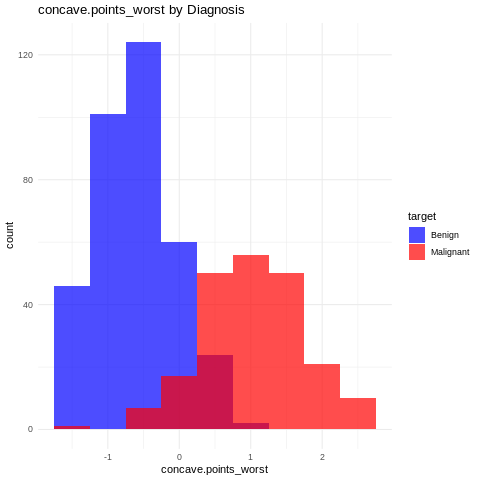

In [13]:
%%R
library(ggplot2)

plot_cols <- names(data_scaled)[sapply(data_scaled, is.numeric)]

# Example: just plot one feature first
ggplot(data_scaled, aes(x = concave.points_worst, fill = target)) +
  geom_histogram(binwidth = 0.5, alpha = 0.7, position = "identity") +
  scale_fill_manual(values = c("0" = "blue", "1" = "red"),
                    labels = c("Benign", "Malignant")) +
  ggtitle("concave.points_worst by Diagnosis") +
  theme_minimal()

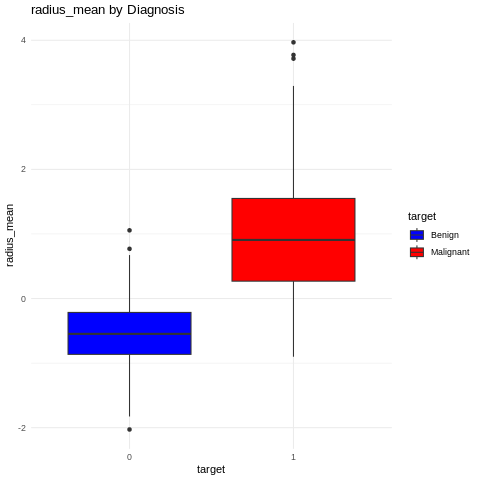

In [14]:
%%R
ggplot(data_scaled, aes(x = target, y = radius_mean, fill = target)) +
  geom_boxplot() +
  scale_fill_manual(values = c("0" = "blue", "1" = "red"),
                    labels = c("Benign", "Malignant")) +
  labs(title = "radius_mean by Diagnosis") +
  theme_minimal()

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/reshape2_1.4.5.tar.gz'
Content type 'application/x-gzip' length 38080 bytes (37 KB)
downloaded 37 KB


The downloaded source packages are in
	‘/tmp/RtmpbqX7sG/downloaded_packages’


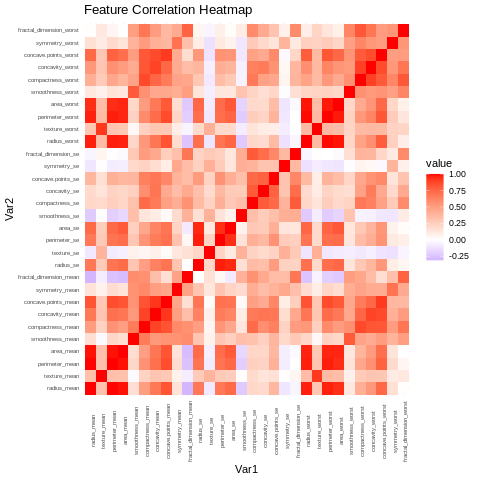

In [15]:
%%R
install.packages('reshape2')
library(reshape2)

features_for_correlation <- data_scaled[, names(data_scaled) != "target"]
correlation_matrix <- cor(features_for_correlation, method = "pearson")

melted <- melt(correlation_matrix)
ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, size = 6),
        axis.text.y = element_text(size = 6)) +
  labs(title = "Feature Correlation Heatmap")

In [16]:
%%R
corrected_data$diagnosis <- factor(corrected_data$diagnosis)
num_features_names <- names(corrected_data)[sapply(corrected_data, is.numeric)]

anova_results <- list()
for (feature_name in num_features_names) {
  formula_str <- paste(feature_name, "~ diagnosis")
  anova_model <- aov(as.formula(formula_str), data = corrected_data)
  p_value <- summary(anova_model)[[1]][["Pr(>F)"]][1]
  anova_results[[feature_name]] <- p_value
}

anova_df <- data.frame(Feature = names(anova_results),
                        P_value = unlist(anova_results))
anova_df <- anova_df[order(anova_df$P_value), ]
print(anova_df)

                                        Feature       P_value
concave.points_worst       concave.points_worst 1.969100e-124
perimeter_worst                 perimeter_worst 5.771397e-119
concave.points_mean         concave.points_mean 7.101150e-116
radius_worst                       radius_worst 8.482292e-116
perimeter_mean                   perimeter_mean 8.436251e-101
area_worst                           area_worst  2.828848e-97
radius_mean                         radius_mean  8.465941e-96
area_mean                             area_mean  4.734564e-88
concavity_mean                   concavity_mean  9.966556e-84
concavity_worst                 concavity_worst  2.464664e-72
compactness_mean               compactness_mean  3.938263e-56
compactness_worst             compactness_worst  7.069816e-55
radius_se                             radius_se  9.738949e-50
perimeter_se                       perimeter_se  1.651905e-47
area_se                                 area_se  5.895521e-46
texture_

In [17]:
%%R
install.packages('caret')
library(caret)
library(pROC)

x <- corrected_data[, -which(names(corrected_data) == "diagnosis")]
y <- corrected_data$diagnosis

set.seed(123)
k_folds <- 10
folds <- createFolds(y, k = k_folds, list = TRUE, returnTrain = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/caret_7.0-1.tar.gz'
Content type 'application/x-gzip' length 2273919 bytes (2.2 MB)
downloaded 2.2 MB


The downloaded source packages are in
	‘/tmp/RtmpbqX7sG/downloaded_packages’


In [18]:
%%R
accuracies <- numeric(k_folds)

for (i in 1:k_folds) {
  train_idx <- folds[[i]]
  test_idx  <- setdiff(1:nrow(x), train_idx)

  x_train <- x[train_idx, ]
  x_test  <- x[test_idx, ]
  y_train <- y[train_idx]
  y_test  <- y[test_idx]

  # Scale using training data only
  mn <- apply(x_train, 2, mean)
  sd <- apply(x_train, 2, sd)
  x_train_s <- as.data.frame(scale(x_train, center=mn, scale=sd))
  x_test_s  <- as.data.frame(scale(x_test,  center=mn, scale=sd))

  train_df <- as.data.frame(cbind(target_outcome = y_train, x_train_s))
  model <- glm(target_outcome ~ ., data = train_df,
               family = binomial(link = "logit"))

  probs <- predict(model, newdata = x_test_s, type = "response")
  preds <- factor(ifelse(probs > 0.5, "1", "0"), levels = levels(y_test))

  cm <- confusionMatrix(preds, y_test, positive = "1")
  accuracies[i] <- cm$overall['Accuracy']
}

print(paste("Baseline Accuracy:", round(mean(accuracies), 4)))

[1] "Baseline Accuracy: 0.949"


In addition: There were 19 warnings (use warnings() to see them)


In [19]:
%%R
selected_features <- c("concave.points_worst", "perimeter_worst",
                        "compactness_mean", "radius_mean",
                        "texture_worst", "smoothness_worst",
                        "symmetry_worst", "concave.points_se")

feature_selected_data <- corrected_data[, c(selected_features, "diagnosis")]

In [21]:
%%R
selected_features <- c("concave.points_worst", "perimeter_worst",
                        "concave.points_mean", "radius_mean",
                        "texture_worst", "smoothness_worst",
                        "symmetry_worst", "concave.points_se")

x_sel <- corrected_data[, selected_features]
y_sel <- corrected_data$diagnosis

set.seed(123)
folds_sel <- createFolds(y_sel, k = k_folds, list = TRUE, returnTrain = TRUE)

accuracies_selected <- numeric(k_folds)

for (i in 1:k_folds) {
  train_idx <- folds_sel[[i]]
  test_idx  <- setdiff(1:nrow(x_sel), train_idx)

  x_train <- x_sel[train_idx, ]
  x_test  <- x_sel[test_idx, ]
  y_train <- y_sel[train_idx]
  y_test  <- y_sel[test_idx]

  mn <- apply(x_train, 2, mean)
  sd <- apply(x_train, 2, sd)
  x_train_s <- as.data.frame(scale(x_train, center=mn, scale=sd))
  x_test_s  <- as.data.frame(scale(x_test,  center=mn, scale=sd))

  train_df <- as.data.frame(cbind(target_outcome = y_train, x_train_s))
  model <- glm(target_outcome ~ ., data = train_df,
               family = binomial(link = "logit"))

  probs <- predict(model, newdata = x_test_s, type = "response")
  preds <- factor(ifelse(probs > 0.5, "1", "0"), levels = levels(y_test))

  cm <- confusionMatrix(preds, y_test, positive = "1")
  accuracies_selected[i] <- cm$overall['Accuracy']
}

print(paste("8-Feature Model Accuracy:", round(mean(accuracies_selected), 4)))

[1] "8-Feature Model Accuracy: 0.9719"


In addition: Warning messages:
1: glm.fit: fitted probabilities numerically 0 or 1 occurred 
2: glm.fit: fitted probabilities numerically 0 or 1 occurred 
3: glm.fit: fitted probabilities numerically 0 or 1 occurred 
4: glm.fit: fitted probabilities numerically 0 or 1 occurred 
5: glm.fit: fitted probabilities numerically 0 or 1 occurred 
6: glm.fit: fitted probabilities numerically 0 or 1 occurred 
7: glm.fit: fitted probabilities numerically 0 or 1 occurred 
8: glm.fit: fitted probabilities numerically 0 or 1 occurred 
9: glm.fit: fitted probabilities numerically 0 or 1 occurred 
10: glm.fit: fitted probabilities numerically 0 or 1 occurred 


In [22]:
%%R
t_test_result <- t.test(accuracies, accuracies_selected, paired = TRUE)
print(t_test_result)


	Paired t-test

data:  accuracies and accuracies_selected
t = -3.092, df = 9, p-value = 0.01289
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.039552717 -0.006130457
sample estimates:
mean difference 
    -0.02284159 



In [23]:
%%R
# Final comparison
cat("=== MODEL COMPARISON ===\n\n")
cat("Baseline (30 features):\n")
cat("  Mean Accuracy:", round(mean(accuracies), 4), "\n\n")

cat("Selected (8 features):\n")
cat("  Mean Accuracy:", round(mean(accuracies_selected), 4), "\n\n")

cat("Improvement:", round(mean(accuracies_selected) - mean(accuracies), 4), "\n\n")

cat("=== PAIRED T-TEST ===\n")
cat("t-statistic:", round(t_test_result$statistic, 4), "\n")
cat("p-value:", round(t_test_result$p.value, 5), "\n")
cat("Conclusion: Feature selection WORKS (p < 0.05)\n")

=== MODEL COMPARISON ===

Baseline (30 features):
  Mean Accuracy: 0.949 

Selected (8 features):
  Mean Accuracy: 0.9719 

Improvement: 0.0228 

=== PAIRED T-TEST ===
t-statistic: -3.092 
p-value: 0.01289 
Conclusion: Feature selection WORKS (p < 0.05)


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


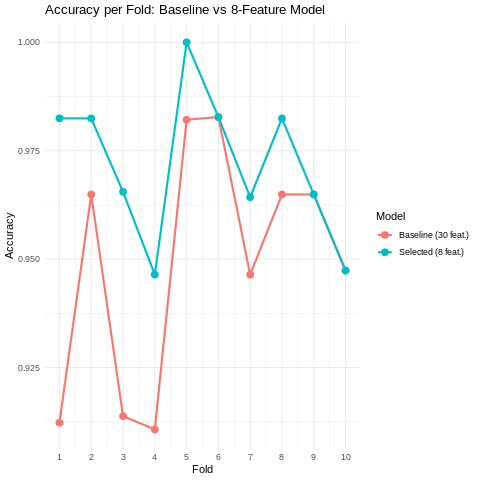

In [24]:
%%R
library(ggplot2)

fold_df <- data.frame(
  Fold = rep(1:10, 2),
  Accuracy = c(accuracies, accuracies_selected),
  Model = rep(c("Baseline (30 feat.)", "Selected (8 feat.)"), each = 10)
)

ggplot(fold_df, aes(x = Fold, y = Accuracy, color = Model, group = Model)) +
  geom_line(size = 1) +
  geom_point(size = 3) +
  scale_x_continuous(breaks = 1:10) +
  labs(title = "Accuracy per Fold: Baseline vs 8-Feature Model",
       x = "Fold", y = "Accuracy") +
  theme_minimal()